<a href="https://colab.research.google.com/github/lgiraldo9/Attention_Control/blob/main/intel_negocio_ejec_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MANEJO DE DATOS FALTANTES(CATEGORICO)


In [44]:
#importando las librerias
import pandas as pd
import seaborn as sns
import numpy as np




In [45]:
#leer dataset
ruta = "/content/dataset_datos_faltantes_categoricos.csv"
datos = pd.read_csv(ruta)


In [46]:
#mostrar datos
datos

,sexo,peso (kg),altura (cm)
0,femenino,60.0,160.0
1,masculino,69.0,170.0
2,masculino,73.0,167.0
3,NaN,81.0,170.0
4,masculino,80.0,170.0
...,...,...,...
595,femenino,65.0,164.0
596,femenino,63.0,160.0
597,masculino,70.0,163.0
598,masculino,75.0,169.0


<Axes: xlabel='peso (kg)', ylabel='Count'>

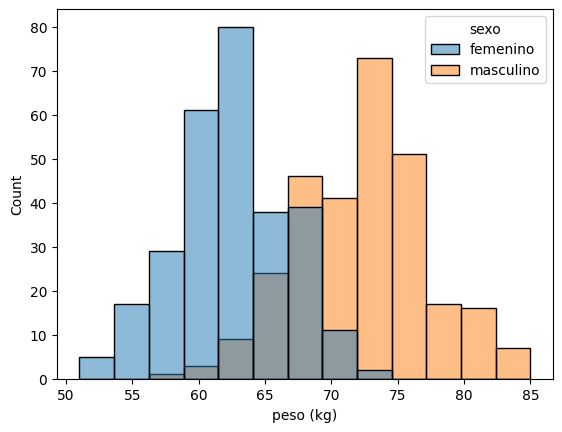

In [47]:
#graficar datos
sns.histplot(data=datos, x='peso (kg)', hue="sexo")

<Axes: xlabel='altura (cm)', ylabel='Count'>

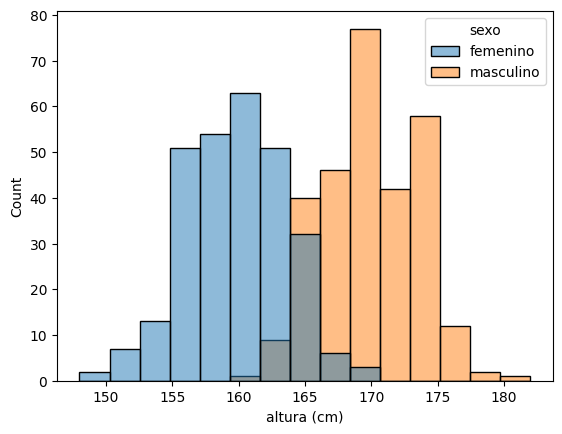

In [48]:
sns.histplot(data=datos, x='altura (cm)', hue='sexo')

In [49]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sexo         570 non-null    object 
 1   peso (kg)    600 non-null    float64
 2   altura (cm)  600 non-null    float64
dtypes: float64(2), object(1)
memory usage: 14.2+ KB


In [50]:
datos.isna().sum()

,0
sexo,30
peso (kg),0
altura (cm),0


In [51]:
datos['sexo'].value_counts()

,count
sexo,
masculino,288
femenino,282


#FORMA DE MANEJAR DATOS FALTANTES

1. eliminar las filas con los registros faltantes
2. eliminar la comlumn(problematica)
3. imputar con la categoria mas frecuente
4. imputar usando machine learning(mas recomendada)

In [52]:
#eliminar las filas
df_filas = datos.dropna(axis=0)#elimina las filas donde no hay registrol


In [53]:
df_filas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 570 entries, 0 to 599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sexo         570 non-null    object 
 1   peso (kg)    570 non-null    float64
 2   altura (cm)  570 non-null    float64
dtypes: float64(2), object(1)
memory usage: 17.8+ KB


In [54]:
#eliminar columnna
df_columna = datos.dropna(axis=1)

In [55]:
df_columna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   peso (kg)    600 non-null    float64
 1   altura (cm)  600 non-null    float64
dtypes: float64(2)
memory usage: 9.5 KB


In [56]:
datos['sexo'].value_counts()

,count
sexo,
masculino,288
femenino,282


In [57]:
df_frec = datos.copy()
df_frec['sexo'] = df_frec['sexo'].fillna('masculino')
df_frec['sexo'].value_counts()

,count
sexo,
masculino,318
femenino,282


In [58]:
df_frec

,sexo,peso (kg),altura (cm)
0,femenino,60.0,160.0
1,masculino,69.0,170.0
2,masculino,73.0,167.0
3,masculino,81.0,170.0
4,masculino,80.0,170.0
...,...,...,...
595,femenino,65.0,164.0
596,femenino,63.0,160.0
597,masculino,70.0,163.0
598,masculino,75.0,169.0


In [59]:
#set de entrenamiento
xy = datos.dropna().to_numpy()
xy.shape

(570, 3)

In [60]:
x_train = xy[:,1:3]
y_train = xy[:,0]

print(x_train)
print(y_train)

[[60.0 160.0]
 [69.0 170.0]
 [73.0 167.0]
 ...
 [70.0 163.0]
 [75.0 169.0]
 [66.0 157.0]]
['femenino' 'masculino' 'masculino' 'masculino' 'femenino' 'femenino'
 'femenino' 'femenino' 'femenino' 'femenino' 'femenino' 'masculino'
 'masculino' 'femenino' 'femenino' 'femenino' 'masculino' 'femenino'
 'femenino' 'masculino' 'femenino' 'femenino' 'masculino' 'masculino'
 'femenino' 'masculino' 'femenino' 'femenino' 'masculino' 'masculino'
 'masculino' 'femenino' 'femenino' 'masculino' 'masculino' 'masculino'
 'masculino' 'masculino' 'masculino' 'masculino' 'femenino' 'masculino'
 'femenino' 'femenino' 'masculino' 'masculino' 'masculino' 'femenino'
 'femenino' 'masculino' 'femenino' 'masculino' 'femenino' 'femenino'
 'femenino' 'masculino' 'masculino' 'masculino' 'masculino' 'femenino'
 'masculino' 'masculino' 'masculino' 'masculino' 'masculino' 'masculino'
 'masculino' 'masculino' 'femenino' 'femenino' 'masculino' 'femenino'
 'masculino' 'femenino' 'femenino' 'masculino' 'masculino' 'masculi

In [61]:
fila = datos[~datos['sexo'].notna()].index
x_test = datos[['peso (kg)','altura (cm)']].iloc[fila].to_numpy()
x_test

array([[ 81., 170.],
       [ 68., 166.],
       [ 62., 164.],
       [ 63., 153.],
       [ 57., 155.],
       [ 63., 163.],
       [ 73., 176.],
       [ 64., 167.],
       [ 71., 168.],
       [ 80., 163.],
       [ 69., 157.],
       [ 58., 167.],
       [ 72., 173.],
       [ 62., 159.],
       [ 66., 155.],
       [ 66., 162.],
       [ 58., 161.],
       [ 87., 171.],
       [ 68., 169.],
       [ 67., 161.],
       [ 58., 160.],
       [ 62., 155.],
       [ 63., 153.],
       [ 70., 166.],
       [ 60., 162.],
       [ 65., 159.],
       [ 71., 169.],
       [ 70., 172.],
       [ 63., 165.],
       [ 63., 164.]])

In [62]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y_train)
le.classes_

array(['femenino', 'masculino'], dtype=object)

In [63]:
y_train = le.transform(y_train)
y_train

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,

In [64]:
le.inverse_transform([0,1,1,0])

array(['femenino', 'masculino', 'masculino', 'femenino'], dtype=object)

In [65]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
#entrenar el modelo con fit
lr.fit(x_train, y_train)

LogisticRegression()

In [66]:
entrada = [[69.,120.]]
predecir = lr.predict(entrada)
predecir

array([0])

In [67]:
cat = le.inverse_transform(predecir)
cat
print(predecir)
print(cat)

[0]
['femenino']


In [68]:
preds = lr.predict(x_test)
print(preds)

[1 1 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 1 0 0]


In [69]:
cats = le.inverse_transform(preds)
print(cats)

['masculino' 'masculino' 'femenino' 'femenino' 'femenino' 'femenino'
 'masculino' 'masculino' 'masculino' 'masculino' 'femenino' 'femenino'
 'masculino' 'femenino' 'femenino' 'femenino' 'femenino' 'masculino'
 'masculino' 'femenino' 'femenino' 'femenino' 'femenino' 'masculino'
 'femenino' 'femenino' 'masculino' 'masculino' 'femenino' 'femenino']


In [70]:
df_ml = datos.copy()
df_ml.iloc[fila,0] = cats
df_ml

,sexo,peso (kg),altura (cm)
0,femenino,60.0,160.0
1,masculino,69.0,170.0
2,masculino,73.0,167.0
3,masculino,81.0,170.0
4,masculino,80.0,170.0
...,...,...,...
595,femenino,65.0,164.0
596,femenino,63.0,160.0
597,masculino,70.0,163.0
598,masculino,75.0,169.0


In [71]:
df_ml["sexo"].isna().sum()

np.int64(0)

In [72]:
df_ml.to_csv("DB_tratada.csv", index = False )
print("archivo guardado corectamente")

archivo guardado corectamente


In [73]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
#descargar la base de datos csv
from google.colab import files
files.download('DB_tratada.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
#trabajar la base de datos desde google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
